# Neural Networks (part 2)

## 1. Introduction 
In this notebook you create a NN for recognizing handwritten digits or fashion items.

#### Refrences:

***MNIST dataset***: Deng, L. (2012). The mnist database of handwritten digit images for machine learning research. IEEE Signal Processing Magazine, 29(6), 141–142.

***Fashion dataset***: Han Xiao and Kashif Rasul and Roland Vollgraf, Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms, arXiv, cs.LG/1708.07747


## 2. Loading the data

You make use of the MNIST or the Fashion-MINST dataset. **You get to choose one of them!** Both datasets consist of 70000 images of 28$\times$28 pixels (each pixel has a gray value 0 - 255). The dataset can be downloaded from the internet (see code below). In the text I reference to the images as numbers, if you do the fashion dataset, you can read here fashion items instead.

In [1]:
# importing the required modules
import numpy as np
import matplotlib.pyplot as plt

# to get matplot figures render correctly in the notebook use:
%matplotlib inline

In [2]:
# Load data from https://www.openml.org/

from sklearn.datasets import fetch_openml

# Pick either the numbers or the fashion database here:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False, parser='auto')
#X, y = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)


X = X.T  # required as the rows should be the features and the columns the samples; shape (784, 70000).
y = y.astype('int')  # y has values as strings ('0', '1', ...'9') and we want integers (0, 1, ..., 9)

# inspect shape.
print(X.shape)
print(y.shape)


(784, 70000)
(70000,)


To have an idea of the data let's print a single sample

label = 0


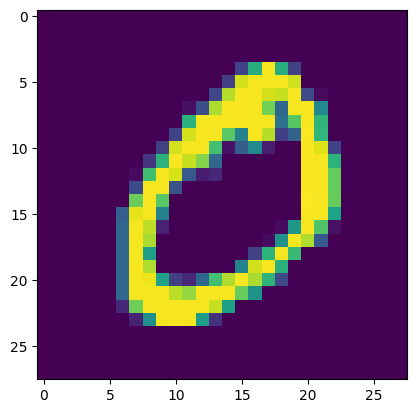

In [3]:
sample = X[:, 1]  # sample number 1
label = y[1]  # label of sample 1
plt.imshow(sample.reshape(28, 28))  # need to reshape to a square image of 28 by 28
print(f'label = {label}')

## 3. Create the feature matrix X and labels matrix Y


In [4]:
# rescale feature matrix to values between 0 and 1
X_norm = (X - np.min(X, axis=0)) / (np.max(X, axis=0) - np.min(X, axis=0))

# create one-hot encoded Y matrix
y_hot = np.zeros(shape=(10, 70000))

for i in range(10):
    y_hot[i, :] = (y == i)


In [5]:
# create a train, validation and test dataset
# for the test data set take the first 5000 samples
# for the train data set take sample 5001 to 60000
# for the validation set take sample 60001 to 70000

X_test = X_norm[:, :5001]
X_train = X_norm[:, 5001:60001]
X_valid = X_norm[:, 60001:]

Y_test = y_hot[:, :5001]
Y_train = y_hot[:, 5001:60001]
Y_valid = y_hot[:, 60001:]


## 4. The Neural Network

The NN that you will make has the following layout (this is something that will work, but feel free to make changes if you like):

- input layer ($l=0$): 784 nodes
- hidden layer ($l=1$): 300 nodes; ReLu activation function
- hidden layer ($l=2$): 100 nodes; ReLu activation function
- output layer ($l=3$): 10 nodes; Softmax activation function


### Define the activation functions

Below you define the required activation functions and their derivatives.

In [7]:
# define some activation functions

def sigmoid(z):
    """
    returns the sigmoid function of z

    Parameters
    ----------
    z : float or ndarray

    Returns
    -------
    out : same type and shape as z

    """

    return 1 / (1 + np.exp(-z))


def sigmoid_diff(z):
    """
    returns the derivative of the sigmoid function of z

    Parameters
    ----------
    z : float or ndarray

    Returns
    -------
    out : same type and shape as z

    """

    sigma = sigmoid(z)

    return sigma * (1 - sigma)


def relu(z):
    """
    returns the relu function of z

    Parameters
    ----------
    z : float or ndarray

    Returns
    -------
    out : same type and shape as z

    """

    return np.max(z)


def relu_diff(z):
    """
    returns the derivative of the relu function of z

    Parameters
    ----------
    z : float or ndarray

    Returns
    -------
    out : same type and shape as z

    """

    return z > 0


def softmax(z):
    """
    returns the softmax function of z

    Parameters
    ----------
    z : 2D ndarray

    Returns
    -------
    out : same type and shape as z

    """

    e = np.exp(z)

    return e / np.sum(e, axis=0)

### Initalize the weights and biases


In [8]:
def initialize_weights_biases(layers):
    W = []
    b = []

    for l in range(1, len(layers)):
        nl = layers[l]
        nl_minus_1 = layers[l - 1]
        W.append(np.random.normal(scale=np.sqrt(1 / nl_minus_1), size=(nl, nl_minus_1)))
        b.append(np.zeros(shape=(nl, 1)))

    return W, b

In [14]:
# intialize the neural network
rng = np.random.default_rng()

# number of nodes in each layer
layers = [784, 300, 100, 10]

W, b = initialize_weights_biases(layers)

## 5. Train the NN

Firt you define three parameters that can be adjusted for optimal training.
- **learning_rate**: determines to what extend we update the weights and biases in the gradient descent step
- **no_epochs**: the number of times we pass the training data set through the network for training
- **batch_size**: how many samples we pass through the network before doing a gradient descent update

In [48]:
# train settings
learning_rate = 0.3
no_epochs = 10
batch_size = 256

Below you implement the training of the network. As a start copy and paste your code from part 1. Note that we use the **Cross Entropy** (CE) loss function.

In [49]:
def forward_pass(W, b, X):
    
    #Forward pass
    als = [X]
    zls = [] #will store values from l=1 to l=L
    for l in range(len(b)):
        zls.append(W[l]@als[-1]+b[l])
        
        if l == len(b) - 1:
            als.append(softmax(zls[-1]))
        else:
            als.append(sigmoid(zls[-1]))
    
    return als, zls       

def backward_pass(W, b, y, als, zls):
    dLdWs = []
    dLdzls = [als[-1] - y] 
    
    for l in range(len(b) - 1, 0, -1):  # Start from last hidden layer
        dLdzls.insert(0, sigmoid_diff(zls[l-1]) * (W[l].T @ dLdzls[0]))
        dLdWs.insert(0, dLdzls[0] @ als[l-1].T)
    
    return dLdWs, dLdzls

    
def update_weigths_biases(W, b, dLdWs, dLdbls):
    prefactor = learning_rate*1/batch_size
    for l in range(len(b)-1):
        
        W[l] = W[l] - prefactor*dLdWs[l]
        
        b[l] = b[l] - prefactor*np.sum(dLdbls[l], axis=1, keepdims=True)
        
    return W, b

In [50]:
# perform the training

def train_NN(W,b,X_train, y_train, X_valid, y_valid):
    train_accuracies = []
    valid_accuracies = []
    train_losses = []
    valid_losses = []

    for epoch in range(1, no_epochs + 1):
        
        # for each epoch train over all batches
        for batch in range(int(np.floor(len(X_train.T)/batch_size))):
            X_batch = X_train[:, batch_size*batch:(batch_size*(batch+1))]
            Y_batch = y_train[:, batch_size*batch:(batch_size*(batch+1))]
            
            # forward pass
            # compute the output of the network for the batch
            als, zls = forward_pass(W, b, X_batch)
            
            # backward pass
            # compute the derivatives dLdW and dLdb for the layers (use CE loss)
            
            dLdWs, dLdbls = backward_pass(W, b, Y_batch, als, zls)
            
            # gradient descent step / update weights and biases
            W, b = update_weigths_biases(W, b, dLdWs, dLdbls)
        
        # for each epoch evaluate the network performance
        # compute accuracy of train set and store for later analysis
        
        als, _ = forward_pass(W, b, X_train)
        
        predictions = np.zeros_like(als[-1])  # Create a zero matrix of the same shape
        predictions[np.argmax(als[-1], axis=0), np.arange(als[-1].shape[1])] = 1  # Set max to 1
        interim = np.all(predictions == y_train, axis= 0).astype(int)  # Compare with true labels
        
        accuracy = np.mean(interim)
        loss = - np.mean(y_train*np.log(als[-1]))
        
        train_accuracies.append(accuracy)
        train_losses.append(loss)
        
        #Do the same for validation accuracy and loss
        
        als, _ = forward_pass(W, b, X_valid)
        
        predictions = np.zeros_like(als[-1])  # Create a zero matrix of the same shape
        predictions[np.argmax(als[-1], axis=0), np.arange(als[-1].shape[1])] = 1  # Set max to 1
        interim = np.all(predictions == y_valid, axis= 0).astype(int)  # Compare with true labels
        
        accuracy = np.mean(interim)
        loss = - np.mean(y_valid*np.log(als[-1]))
        
        valid_accuracies.append(accuracy)
        valid_losses.append(loss)
        
        # for each epoch print info on learning progress
        print(f"Epoch {epoch} \n Train accuracy: {train_accuracies[-1]:.3} train loss:{train_losses[-1]} \n Validation accuracy: {valid_accuracies[-1]:.3} validation loss:{valid_losses[-1]} \n")
        
    return W, b, train_accuracies, train_losses, valid_accuracies, valid_losses

In [51]:
W, b = initialize_weights_biases(layers)

W, b, train_accuracies, train_losses, valid_accuracies, valid_losses = train_NN(W, b, X_train, Y_train, X_valid, Y_valid)

Epoch 1 
 Train accuracy: 0.599 train loss:0.17243666537941268 
 Validation accuracy: 0.601 validation loss:0.17123459005411554 
Epoch 2 
 Train accuracy: 0.732 train loss:0.1272163841362924 
 Validation accuracy: 0.741 validation loss:0.12579932950274159 
Epoch 3 
 Train accuracy: 0.802 train loss:0.1064086562440072 
 Validation accuracy: 0.812 validation loss:0.10493482139340611 
Epoch 4 
 Train accuracy: 0.838 train loss:0.09423490149837957 
 Validation accuracy: 0.846 validation loss:0.09270768702271037 
Epoch 5 
 Train accuracy: 0.857 train loss:0.08617787071235312 
 Validation accuracy: 0.863 validation loss:0.08462343086670486 
Epoch 6 
 Train accuracy: 0.868 train loss:0.08044063973056903 
 Validation accuracy: 0.877 validation loss:0.07888273835484025 
Epoch 7 
 Train accuracy: 0.876 train loss:0.07613846617109218 
 Validation accuracy: 0.883 validation loss:0.07459258089438633 
Epoch 8 
 Train accuracy: 0.881 train loss:0.07277029144126937 
 Validation accuracy: 0.888 validat

## 6. Analyze the result
Make a plot of the training and validation loss and training and validation accuracy as function of the epoch.

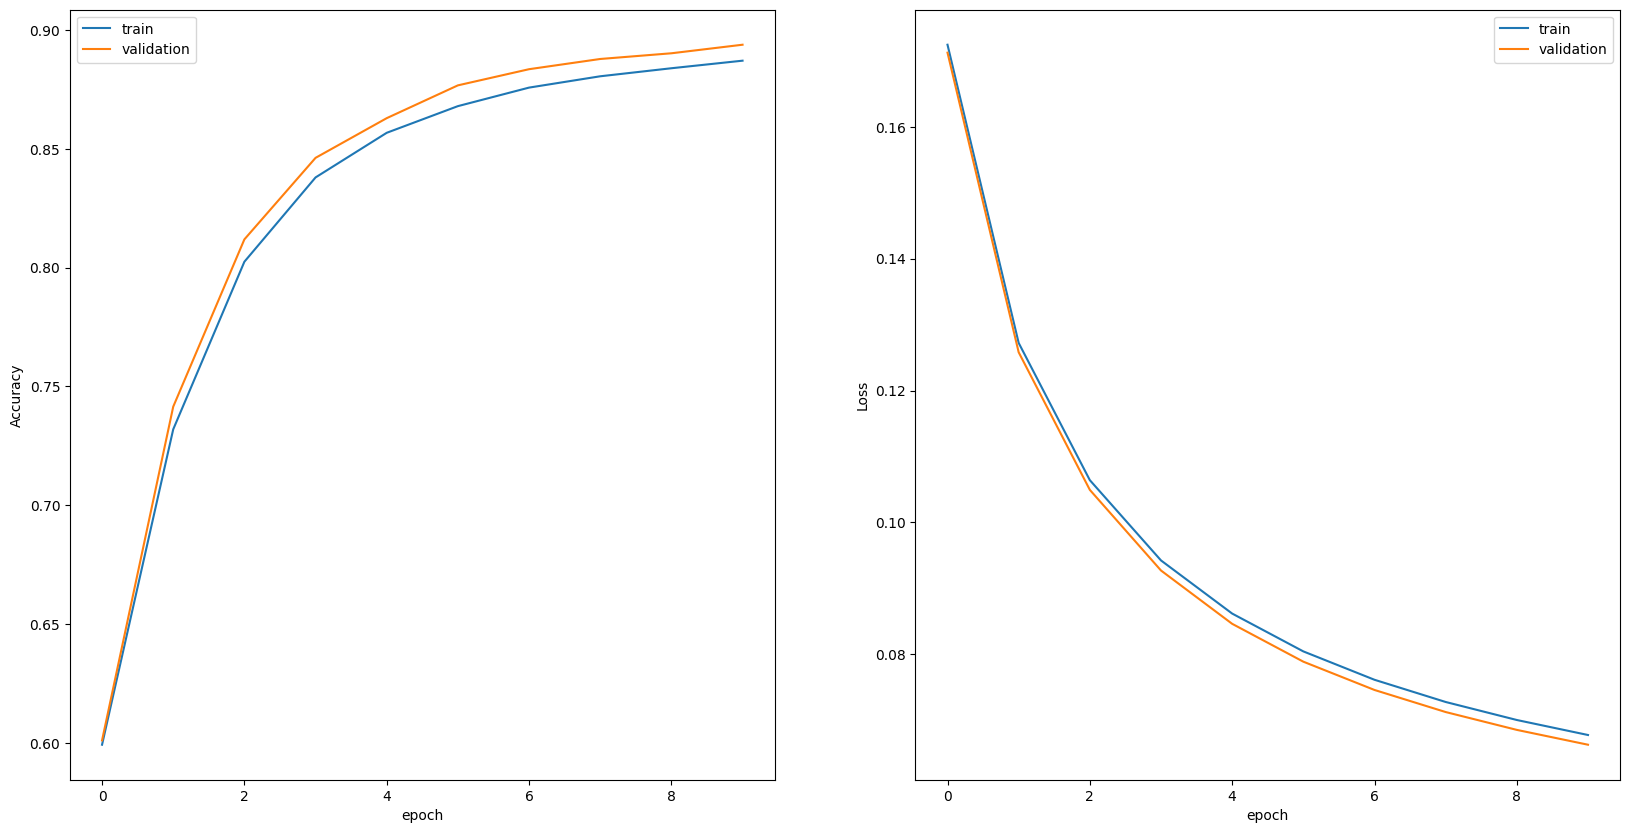

In [53]:
# Plot the loss and accuracy on the train and validation set
fig, axs = plt.subplots(1, 2, figsize=(20, 10))
axs[0].plot(train_accuracies, label="train")
axs[0].plot(valid_accuracies, label="validation")
axs[0].set(xlabel='epoch', ylabel='Accuracy')
axs[0].legend()

axs[1].plot(train_losses, label="train")
axs[1].plot(valid_losses, label="validation")
axs[1].set(xlabel='epoch', ylabel='Loss')
axs[1].legend()


In [54]:
# Compute the accuracy and loss on the test set
als, _ = forward_pass(W, b, X_test)

predictions = np.zeros_like(als[-1])  # Create a zero matrix of the same shape
predictions[np.argmax(als[-1], axis=0), np.arange(als[-1].shape[1])] = 1  # Set max to 1
interim = np.all(predictions == Y_test, axis= 0).astype(int)  # Compare with true labels

accuracy = np.mean(interim)
loss = - np.mean(Y_test*np.log(als[-1]))

print(f"Test accuracy: {accuracy} \n Test loss: {loss}")

Test accuracy: 0.8932213557288542 
 Test loss: 0.06538659523846432


Adapt the hyperparameters and/or NN layout to try to improve the result.

Finally use the test set to check the performance of the model

In [ ]:
# compute the accuracy and losses of the test set
'''YOUR CODE GOES HERE '''

Finally it is interesting to check a few samples and their predicted label

In [ ]:
# check the prediction of 10 random images
'''YOUR CODE GOES HERE '''

# Neural Networks - The autoencoder **(5EC mandatory)**

You are going to train a neural network that is able to generate a new picture of a any on the 0..9 numbers. The shape of the NN resembles that of a bow tie:

- input layer ($l=0$): 784 nodes
- hidden layer ($l=1$): 300 nodes; ReLu activation function   (FIXED)
- hidden layer ($l=2$): 100 nodes; ReLu activation function   (FIXED)    
- hidden layer ($l=3$): 10 nodes; Softmax activation function  (FIXED)
- hidden layer ($l=4$): ? nodes; ? activation function
- hidden layer ($l=5$): ? nodes; ? activation function
- output layer ($l=6$): 784 nodes; ? activation function

You can train it by passing pictures trough it, the outgoing picture should be almost identical. Think about what loss function would be most appropriate here. Use the weights of the previously trained NN for the left side of the 'bow tie'. This setup is also known as an **autoencoder**. Layers 1-3 function as the _encoder_, wheras the layers 4-6 are the _decoder_. It can be used to find a compressed version of your input data. In case the loss is zero, you have obtained a perfect compression.

Once training is complete you can use the right hand side of the bow tie to generate a new image starting from the input vector, for example, a3 = np.zeros((10)),  a3[3]=1 and see if you get a figure back that resembles a 2.

**Deliverables:** 
1. A plot of 10 newly generated numbers with your network.
2. An outputweights.npz file with all weights and biases of your filal Neural Network (encoder and decoder)
3. A code to read in the outputweights.npz file and use the image generator

_Deliverable 1 could look like:_

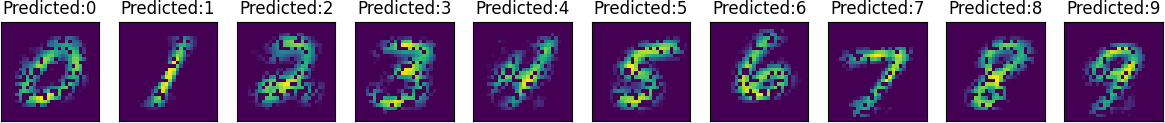
_It would be great if some of you manage to find a solution for the dark (missing) pixels!_     

_Or in case of the fashion set:_

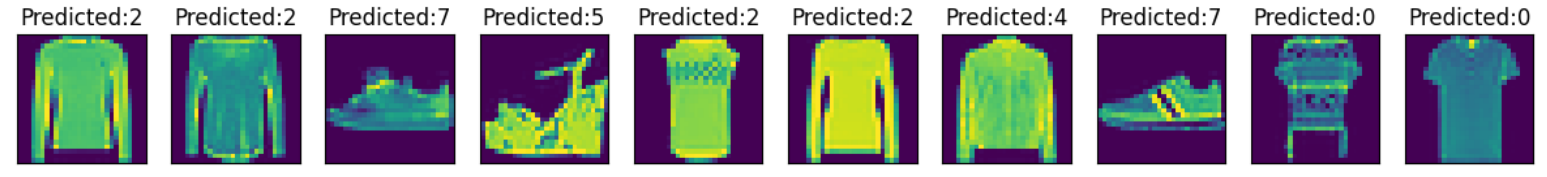

In [ ]:
# Setup the Network



In [ ]:
# Train the decoder



In [ ]:
# Test your image generation and improve your training procedure (hyperparameter tuning)



### Deliverable 1 

In [ ]:
# Prove that your network does what it should do and present your deliverable convincingly!



### Deliverable 2                

In [ ]:
## saves the obtained weights
#outfile='totalweightsNN.npz'
#np.savez(outfile, W1,...,b1,...)
#npzfile = np.load(outfile)
#npzfile.files
#W1=npzfile['arr_0']
#W1.shape


### Deliverable 3               